# **Statistical Analysis of Physical Characteristics of Palmer Penguins Using R**

In [50]:
install.packages(c(
  "palmerpenguins",
  "ggplot2",
  "dplyr",
  "moments",
  "car",
  "effectsize"
))

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [51]:
library(palmerpenguins)
library(ggplot2)
library(dplyr)
library(moments)
library(car)
library(effectsize)


Attaching package: ‘palmerpenguins’


The following objects are masked _by_ ‘.GlobalEnv’:

    penguins, penguins_raw


The following objects are masked from ‘package:datasets’:

    penguins, penguins_raw




**Load the Dataset**

In [52]:
data(penguins)

head(penguins)

species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
<fct>,<fct>,<dbl>,<dbl>,<int>,<int>,<fct>,<int>
Adelie,Torgersen,39.1,18.7,181,3750,male,2007
Adelie,Torgersen,39.5,17.4,186,3800,female,2007
Adelie,Torgersen,40.3,18.0,195,3250,female,2007
Adelie,Torgersen,NA,NA,NA,NA,NA,2007
Adelie,Torgersen,36.7,19.3,193,3450,female,2007
Adelie,Torgersen,39.3,20.6,190,3650,male,2007


**Understand the Dataset**

In [53]:
dim(penguins)

[1] 344   8

In [54]:
str(penguins)

tibble [344 × 8] (S3: tbl_df/tbl/data.frame)
 $ species          : Factor w/ 3 levels "Adelie","Chinstrap",..: 1 1 1 1 1 1 1 1 1 1 ...
 $ island           : Factor w/ 3 levels "Biscoe","Dream",..: 3 3 3 3 3 3 3 3 3 3 ...
 $ bill_length_mm   : num [1:344] 39.1 39.5 40.3 NA 36.7 39.3 38.9 39.2 34.1 42 ...
 $ bill_depth_mm    : num [1:344] 18.7 17.4 18 NA 19.3 20.6 17.8 19.6 18.1 20.2 ...
 $ flipper_length_mm: int [1:344] 181 186 195 NA 193 190 181 195 193 190 ...
 $ body_mass_g      : int [1:344] 3750 3800 3250 NA 3450 3650 3625 4675 3475 4250 ...
 $ sex              : Factor w/ 2 levels "female","male": 2 1 1 NA 1 2 1 2 NA NA ...
 $ year             : int [1:344] 2007 2007 2007 2007 2007 2007 2007 2007 2007 2007 ...


In [55]:
summary(penguins)

      species          island    bill_length_mm  bill_depth_mm  
 Adelie   :152   Biscoe   :168   Min.   :32.10   Min.   :13.10  
 Chinstrap: 68   Dream    :124   1st Qu.:39.23   1st Qu.:15.60  
 Gentoo   :124   Torgersen: 52   Median :44.45   Median :17.30  
                                 Mean   :43.92   Mean   :17.15  
                                 3rd Qu.:48.50   3rd Qu.:18.70  
                                 Max.   :59.60   Max.   :21.50  
                                 NAs    :2       NAs    :2      
 flipper_length_mm  body_mass_g       sex           year     
 Min.   :172.0     Min.   :2700   female:165   Min.   :2007  
 1st Qu.:190.0     1st Qu.:3550   male  :168   1st Qu.:2007  
 Median :197.0     Median :4050   NAs   : 11   Median :2008  
 Mean   :200.9     Mean   :4202                Mean   :2008  
 3rd Qu.:213.0     3rd Qu.:4750                3rd Qu.:2009  
 Max.   :231.0     Max.   :6300                Max.   :2009  
 NAs    :2         NAs    :2                  

In [56]:
colSums(is.na(penguins))

species            island    bill_length_mm     bill_depth_mm 
                0                 0                 2                 2 
flipper_length_mm       body_mass_g               sex              year 
                2                 2                11                 0

**Remove Missing Values**

In [58]:
library(dplyr)
penguins_clean <- penguins %>%
  filter(
    !is.na(body_mass_g),
    !is.na(flipper_length_mm),
    !is.na(species),
    !is.na(sex)
  )

dim(penguins_clean)

[1] 333   8

# **PART A — DESCRIPTIVE STATISTICS**

**Overall Body Mass Statistics**

In [60]:
body_mass <- penguins_clean$body_mass_g

mean(body_mass)
median(body_mass)
min(body_mass)
max(body_mass)
var(body_mass)
sd(body_mass)
quantile(body_mass, 0.25)
quantile(body_mass, 0.75)
IQR(body_mass)

[1] 4207.057

[1] 4050

[1] 2700

[1] 6300

[1] 648372.5

[1] 805.2158

25% 
3550

75% 
4775

[1] 1225

**Proper Descriptive Statistics Table**

In [61]:
descriptive_stats <- data.frame(
  Mean = mean(body_mass),
  Median = median(body_mass),
  Minimum = min(body_mass),
  Maximum = max(body_mass),
  Variance = var(body_mass),
  SD = sd(body_mass),
  Q1 = quantile(body_mass, 0.25),
  Q3 = quantile(body_mass, 0.75),
  IQR = IQR(body_mass)
)

descriptive_stats

,Mean,Median,Minimum,Maximum,Variance,SD,Q1,Q3,IQR
,<dbl>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
25%,4207.057,4050,2700,6300,648372.5,805.2158,3550,4775,1225


**Species-wise Descriptive Statistics**

In [62]:
species_stats <- penguins_clean %>%
  group_by(species) %>%
  summarise(
    Mean = mean(body_mass),
    Median = median(body_mass),
    Minimum = min(body_mass),
    Maximum = max(body_mass),
    Variance = var(body_mass),
    SD = sd(body_mass),
    Q1 = quantile(body_mass, 0.25),
    Q3 = quantile(body_mass, 0.75),
    IQR = IQR(body_mass)
  )

species_stats

species,Mean,Median,Minimum,Maximum,Variance,SD,Q1,Q3,IQR
<fct>,<dbl>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Adelie,4207.057,4050,2700,6300,648372.5,805.2158,3550,4775,1225
Chinstrap,4207.057,4050,2700,6300,648372.5,805.2158,3550,4775,1225
Gentoo,4207.057,4050,2700,6300,648372.5,805.2158,3550,4775,1225


**Histogram**

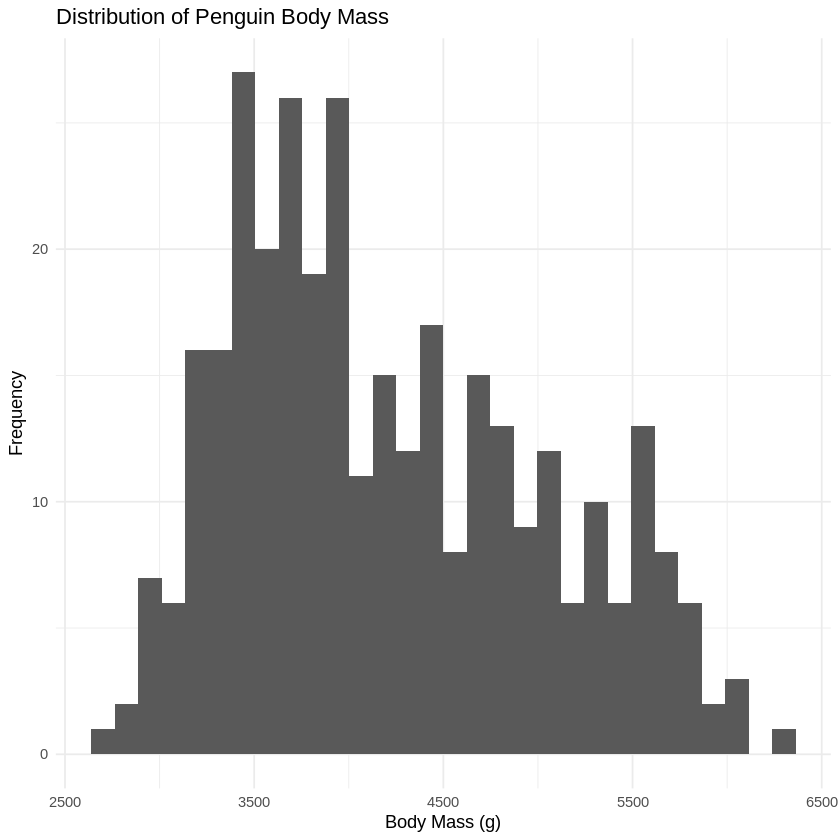

In [63]:
library(ggplot2)
ggplot(penguins_clean, aes(x = body_mass)) +
  geom_histogram(bins = 30) +
  labs(
    title = "Distribution of Penguin Body Mass",
    x = "Body Mass (g)",
    y = "Frequency"
  ) +
  theme_minimal()

**Species-wise Boxplot**

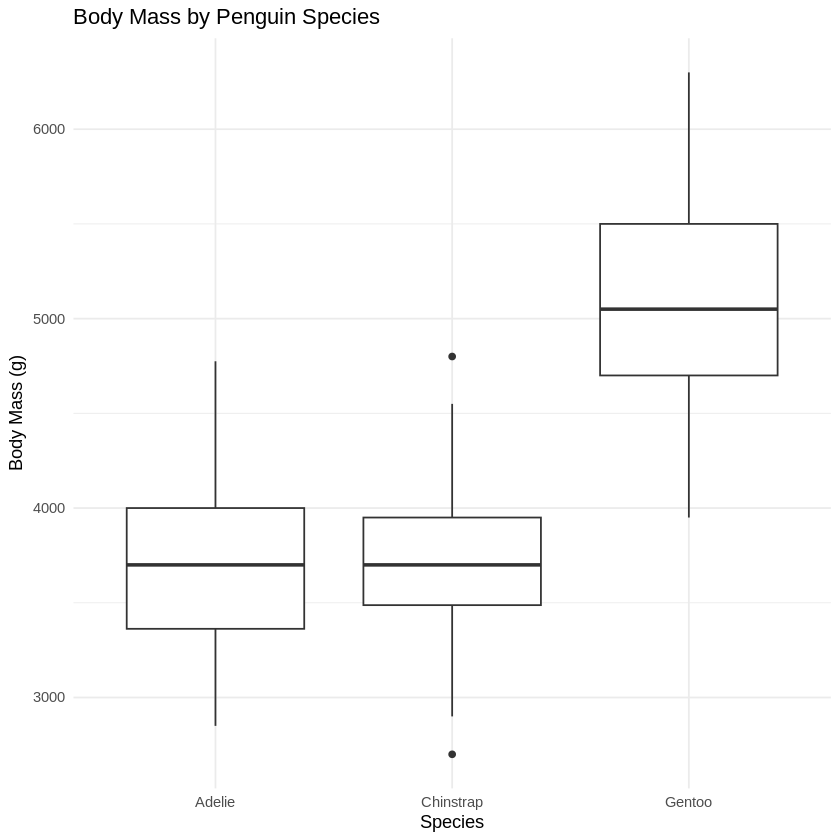

In [64]:
ggplot(penguins_clean, aes(x = species, y = body_mass)) +
  geom_boxplot() +
  labs(
    title = "Body Mass by Penguin Species",
    x = "Species",
    y = "Body Mass (g)"
  ) +
  theme_minimal()

**Density Plot**

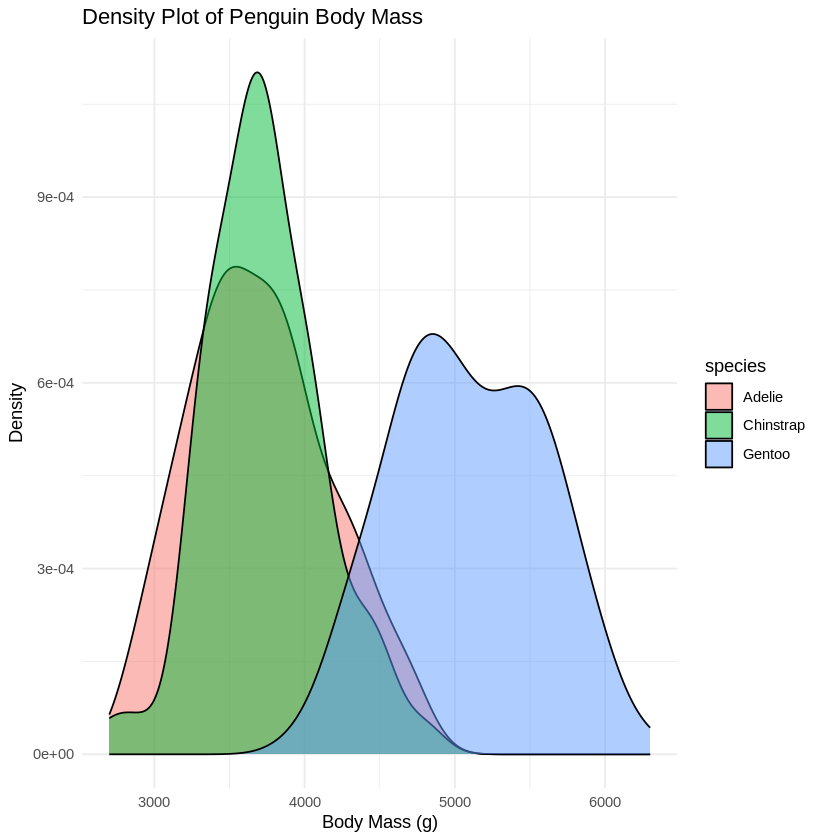

In [65]:
ggplot(penguins_clean, aes(x = body_mass, fill = species)) +
  geom_density(alpha = 0.5) +
  labs(
    title = "Density Plot of Penguin Body Mass",
    x = "Body Mass (g)",
    y = "Density"
  ) +
  theme_minimal()

# **PART B — HYPOTHESIS TESTING**

**State Hypotheses**

**Hypotheses**

H₀: There is no significant difference between the mean body mass of male and female penguins.

H₁: There is a significant difference between the mean body mass of male and female penguins.

Significance level:

α = 0.05

**Check Male/Female Distribution**

In [66]:
table(penguins_clean$sex)


female   male 
   165    168 

**Shapiro-Wilk Normality Test**

In [68]:
male_mass <- penguins_clean %>%
  filter(sex == "male") %>%
  pull(body_mass_g)

female_mass <- penguins_clean %>%
  filter(sex == "female") %>%
  pull(body_mass_g)

shapiro.test(male_mass)
shapiro.test(female_mass)


	Shapiro-Wilk normality test

data:  male_mass
W = 0.92504, p-value = 1.227e-07



	Shapiro-Wilk normality test

data:  female_mass
W = 0.91931, p-value = 6.155e-08


**QQ Plots**

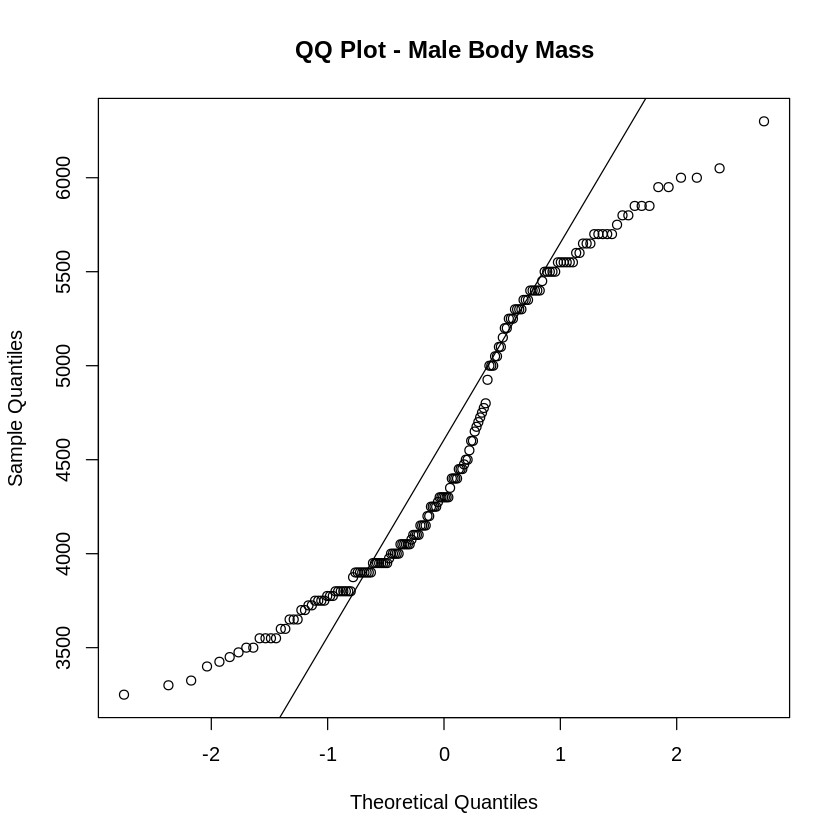

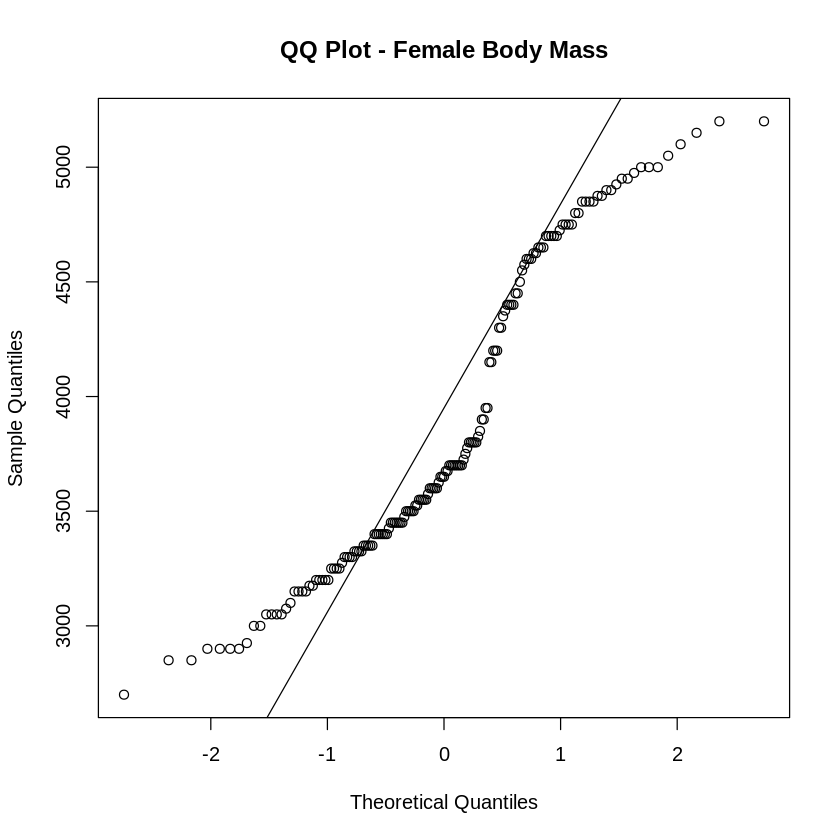

In [69]:
qqnorm(male_mass, main = "QQ Plot - Male Body Mass")
qqline(male_mass)

qqnorm(female_mass, main = "QQ Plot - Female Body Mass")
qqline(female_mass)

**Independent Two-Sample t-Test**

In [70]:
t_test_result <- t.test(
  body_mass ~ sex,
  data = penguins_clean
)

t_test_result


	Welch Two Sample t-test

data:  body_mass by sex
t = -8.5545, df = 323.9, p-value = 4.794e-16
alternative hypothesis: true difference in means between group female and group male is not equal to 0
95 percent confidence interval:
 -840.5783 -526.2453
sample estimates:
mean in group female   mean in group male 
            3862.273             4545.685 


**Cohen's d**

In [71]:
install.packages("effectsize")
library(effectsize)
cohens_d <- cohens_d(
  body_mass ~ sex,
  data = penguins_clean
)

cohens_d

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



Cohens_d,CI,CI_low,CI_high
<dbl>,<dbl>,<dbl>,<dbl>
-0.9362048,0.95,-1.161904,-0.709225


**Sex-wise Boxplot**

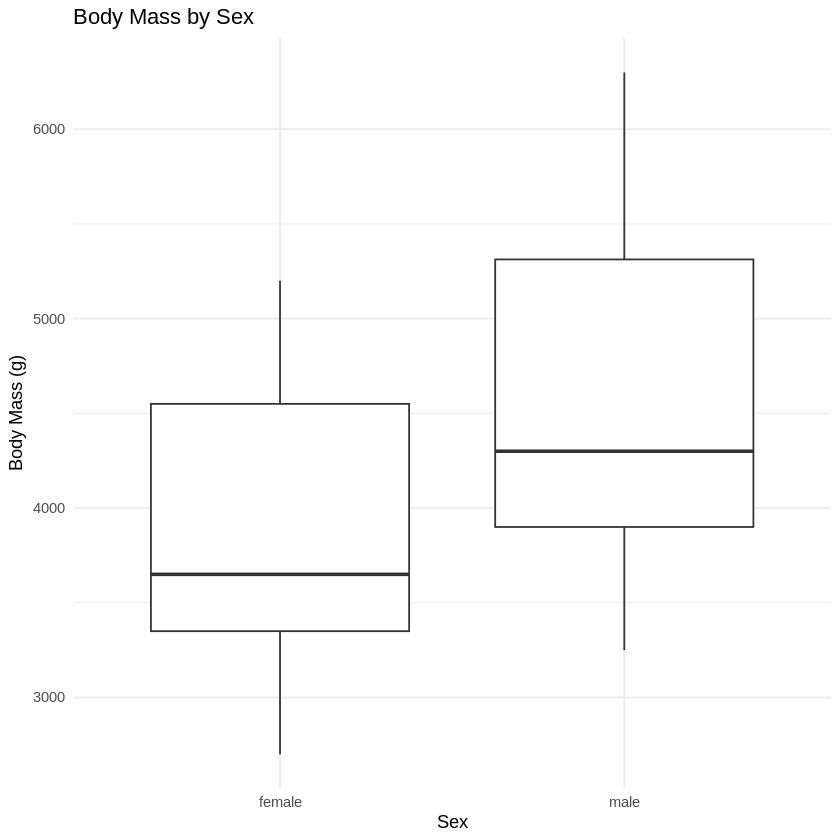

In [72]:
ggplot(penguins_clean, aes(x = sex, y = body_mass)) +
  geom_boxplot() +
  labs(
    title = "Body Mass by Sex",
    x = "Sex",
    y = "Body Mass (g)"
  ) +
  theme_minimal()

# **PART C — ONE-WAY ANOVA**

**ANOVA Hypotheses**

H₀: The mean body mass is equal across all three penguin species.

H₁: At least one species has a different mean body mass.

**Check Normality by Species**

In [74]:
by(
  penguins_clean$body_mass_g,
  penguins_clean$species,
  shapiro.test
)

penguins_clean$species: Adelie

	Shapiro-Wilk normality test

data:  dd[x, ]
W = 0.98116, p-value = 0.04232

------------------------------------------------------------ 
penguins_clean$species: Chinstrap

	Shapiro-Wilk normality test

data:  dd[x, ]
W = 0.98449, p-value = 0.5605

------------------------------------------------------------ 
penguins_clean$species: Gentoo

	Shapiro-Wilk normality test

data:  dd[x, ]
W = 0.98606, p-value = 0.2605


**Species QQ Plots**

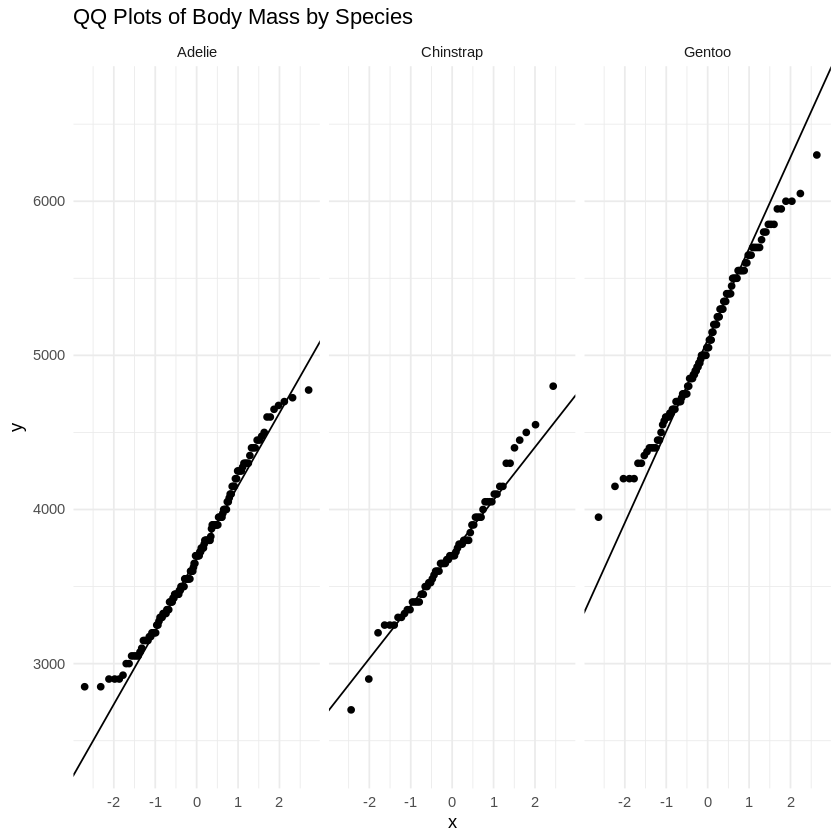

In [75]:
ggplot(penguins_clean, aes(sample = body_mass)) +
  stat_qq() +
  stat_qq_line() +
  facet_wrap(~species) +
  labs(
    title = "QQ Plots of Body Mass by Species"
  ) +
  theme_minimal()

**Levene's Test**

In [76]:
install.packages("car")
library(car)
leveneTest(body_mass ~ species, data = penguins_clean)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,2,5.134899,0.006367054
,330,NA,NA


**Interpretation:**

p > 0.05 → equal variance assumption is reasonable.

p < 0.05 → variance assumption is violated.

**One-Way ANOVA**

In [77]:
anova_model <- aov(
  body_mass_g ~ species,
  data = penguins_clean
)

summary(anova_model)

             Df    Sum Sq  Mean Sq F value Pr(>F)    
species       2 145190219 72595110   341.9 <2e-16 ***
Residuals   330  70069447   212332                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

**Tukey HSD**

In [78]:
tukey_result <- TukeyHSD(anova_model)

tukey_result

  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = body_mass_g ~ species, data = penguins_clean)

$species
                       diff       lwr       upr    p adj
Chinstrap-Adelie   26.92385 -132.3528  186.2005 0.916431
Gentoo-Adelie    1386.27259 1252.2897 1520.2554 0.000000
Gentoo-Chinstrap 1359.34874 1194.4304 1524.2671 0.000000


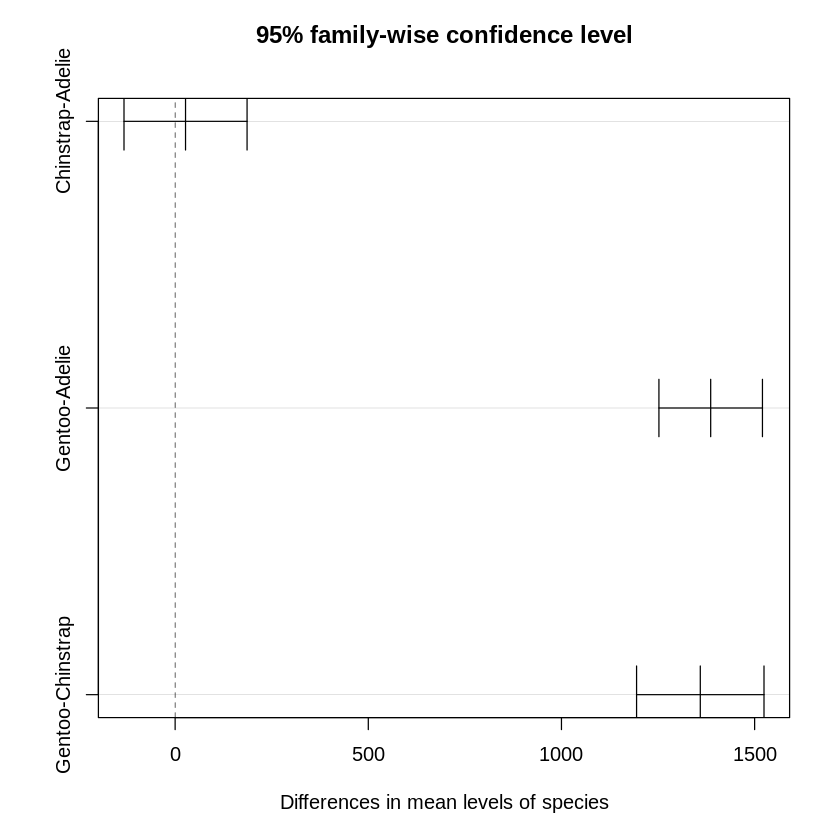

In [79]:
plot(tukey_result)

**Species Comparison Plot**

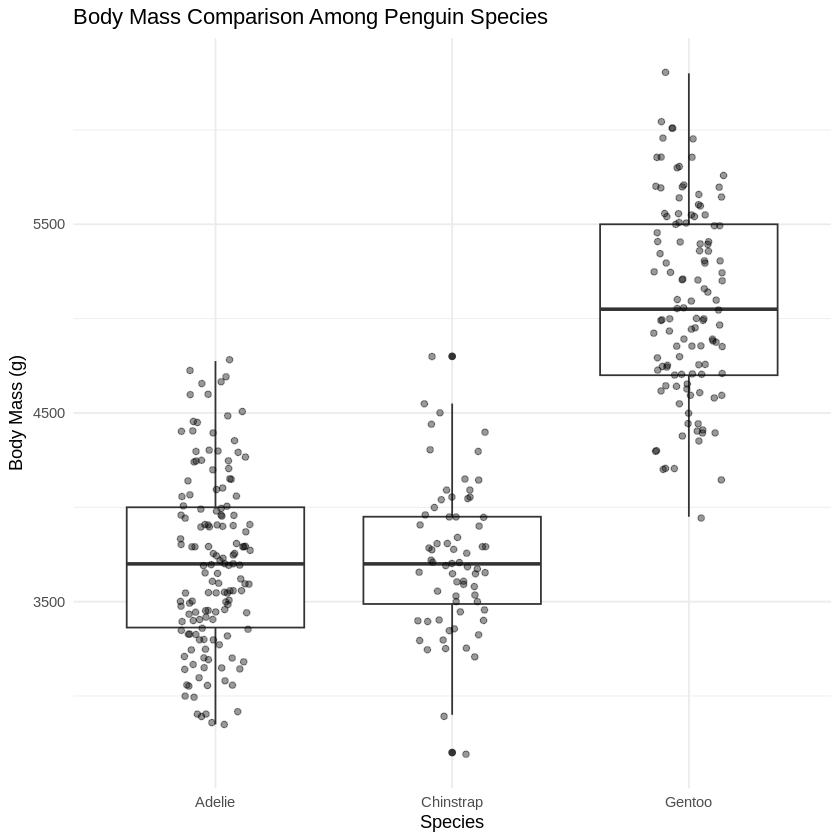

In [80]:
ggplot(penguins_clean, aes(x = species, y = body_mass_g)) +
  geom_boxplot() +
  geom_jitter(width = 0.15, alpha = 0.4) +
  labs(
    title = "Body Mass Comparison Among Penguin Species",
    x = "Species",
    y = "Body Mass (g)"
  ) +
  theme_minimal()

# **PART D — KRUSKAL-WALLIS TEST**

In [81]:
kruskal_result <- kruskal.test(
  body_mass_g ~ species,
  data = penguins_clean
)

kruskal_result


	Kruskal-Wallis rank sum test

data:  body_mass_g by species
Kruskal-Wallis chi-squared = 212.09, df = 2, p-value < 2.2e-16


# **Compare ANOVA and Kruskal-Wallis**

In [82]:
two_way_model <- aov(
  body_mass_g ~ species * sex,
  data = penguins_clean
)

summary(two_way_model)

             Df    Sum Sq  Mean Sq F value   Pr(>F)    
species       2 145190219 72595110 758.358  < 2e-16 ***
sex           1  37090262 37090262 387.460  < 2e-16 ***
species:sex   2   1676557   838278   8.757 0.000197 ***
Residuals   327  31302628    95727                     
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

**Interaction Visualization**

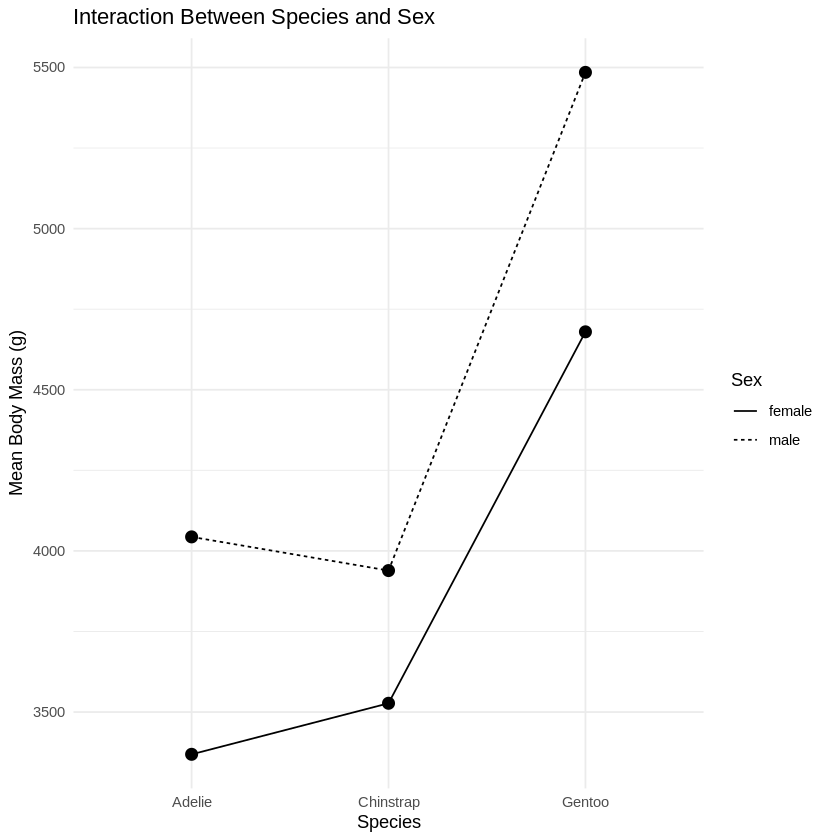

In [83]:
ggplot(
  penguins_clean,
  aes(
    x = species,
    y = body_mass_g,
    group = sex,
    linetype = sex
  )
) +
  stat_summary(
    fun = mean,
    geom = "line"
  ) +
  stat_summary(
    fun = mean,
    geom = "point",
    size = 3
  ) +
  labs(
    title = "Interaction Between Species and Sex",
    x = "Species",
    y = "Mean Body Mass (g)",
    linetype = "Sex"
  ) +
  theme_minimal()

# **PART F — FLIPPER LENGTH ANALYSIS**

In [84]:
flipper_stats <- penguins_clean %>%
  group_by(species) %>%
  summarise(
    Mean = mean(flipper_length_mm),
    Median = median(flipper_length_mm),
    SD = sd(flipper_length_mm),
    Minimum = min(flipper_length_mm),
    Maximum = max(flipper_length_mm),
    IQR = IQR(flipper_length_mm)
  )

flipper_stats

species,Mean,Median,SD,Minimum,Maximum,IQR
<fct>,<dbl>,<dbl>,<dbl>,<int>,<int>,<dbl>
Adelie,190.1027,190,6.521825,172,210,9.0
Chinstrap,195.8235,196,7.131894,178,212,10.0
Gentoo,217.2353,216,6.585431,203,231,9.5


**Flipper Length Boxplot**

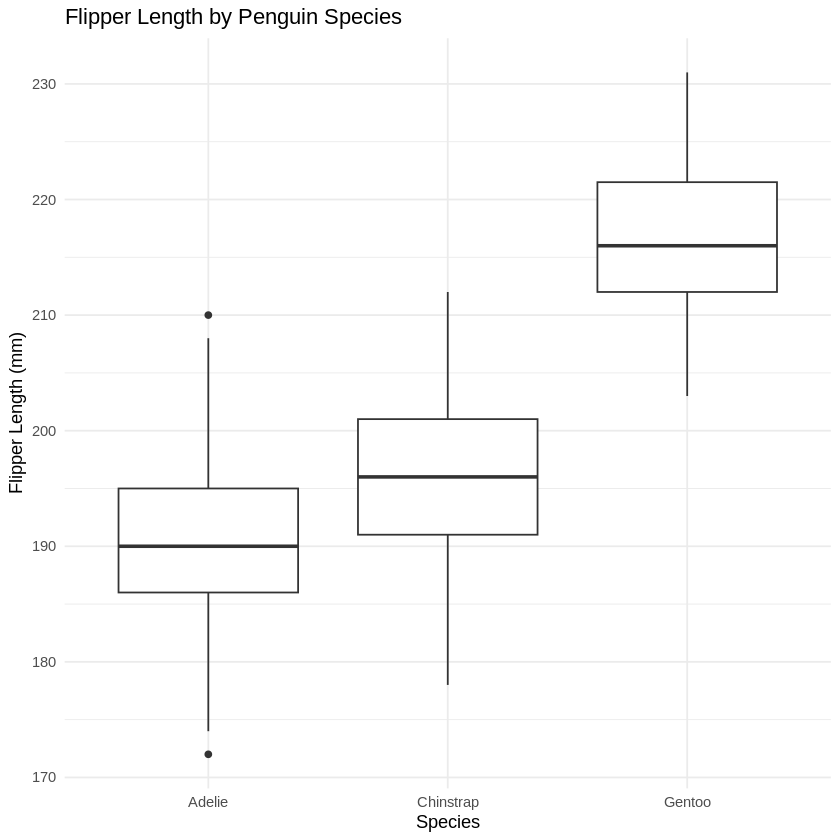

In [85]:
ggplot(
  penguins_clean,
  aes(x = species, y = flipper_length_mm)
) +
  geom_boxplot() +
  labs(
    title = "Flipper Length by Penguin Species",
    x = "Species",
    y = "Flipper Length (mm)"
  ) +
  theme_minimal()

**Flipper Length ANOVA**

In [86]:
flipper_anova <- aov(
  flipper_length_mm ~ species,
  data = penguins_clean
)

summary(flipper_anova)

             Df Sum Sq Mean Sq F value Pr(>F)    
species       2  50526   25263   567.4 <2e-16 ***
Residuals   330  14693      45                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

**Flipper Length Tukey Test**

In [87]:
TukeyHSD(flipper_anova)

  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = flipper_length_mm ~ species, data = penguins_clean)

$species
                     diff       lwr       upr p adj
Chinstrap-Adelie  5.72079  3.414364  8.027215     0
Gentoo-Adelie    27.13255 25.192399 29.072709     0
Gentoo-Chinstrap 21.41176 19.023644 23.799885     0


# **PART G — SAVE RESULTS**

In [88]:
cat("===== PALMER PENGUINS STATISTICAL ANALYSIS =====\n\n")

cat("Descriptive Statistics:\n")
print(descriptive_stats)

cat("\nSpecies-wise Statistics:\n")
print(species_stats)

cat("\n\nIndependent t-test:\n")
print(t_test_result)

cat("\n\nCohen's d:\n")
print(cohens_d)

cat("\n\nOne-way ANOVA:\n")
print(summary(anova_model))

cat("\n\nTukey HSD:\n")
print(tukey_result)

cat("\n\nKruskal-Wallis Test:\n")
print(kruskal_result)

cat("\n\nTwo-way ANOVA:\n")
print(summary(two_way_model))

cat("\n\nFlipper Length ANOVA:\n")
print(summary(flipper_anova))

===== PALMER PENGUINS STATISTICAL ANALYSIS =====

Descriptive Statistics:
        Mean Median Minimum Maximum Variance       SD   Q1   Q3  IQR
25% 4207.057   4050    2700    6300 648372.5 805.2158 3550 4775 1225

Species-wise Statistics:
# A tibble: 3 × 10
  species    Mean Median Minimum Maximum Variance    SD    Q1    Q3   IQR
  <fct>     <dbl>  <int>   <int>   <int>    <dbl> <dbl> <dbl> <dbl> <dbl>
1 Adelie    4207.   4050    2700    6300  648372.  805.  3550  4775  1225
2 Chinstrap 4207.   4050    2700    6300  648372.  805.  3550  4775  1225
3 Gentoo    4207.   4050    2700    6300  648372.  805.  3550  4775  1225


Independent t-test:

	Welch Two Sample t-test

data:  body_mass by sex
t = -8.5545, df = 323.9, p-value = 4.794e-16
alternative hypothesis: true difference in means between group female and group male is not equal to 0
95 percent confidence interval:
 -840.5783 -526.2453
sample estimates:
mean in group female   mean in group male 
            3862.273             4545.